In [174]:
import matplotlib.pyplot as plt
import seaborn as sns

In [175]:
import pandas as pd
df=pd.read_csv('D:\Data Science ML\ML\Predictive maintenance of machines\Predictive-Maintenance-of-Machines-using-Machine-Learning-Models\predictive_maintenance.csv')

<>:2: SyntaxWarning: invalid escape sequence '\D'
<>:2: SyntaxWarning: invalid escape sequence '\D'
C:\Users\Muhammad Aqib\AppData\Local\Temp\ipykernel_19804\2116125010.py:2: SyntaxWarning: invalid escape sequence '\D'
  df=pd.read_csv('D:\Data Science ML\ML\Predictive maintenance of machines\Predictive-Maintenance-of-Machines-using-Machine-Learning-Models\predictive_maintenance.csv')


In [176]:
df=df.drop(['Product ID',"UDI","Target"], axis=1)

In [177]:
df['Failure Type'].value_counts()

Failure Type
No Failure                  9652
Heat Dissipation Failure     112
Power Failure                 95
Overstrain Failure            78
Tool Wear Failure             45
Random Failures               18
Name: count, dtype: int64

In [178]:
df.head()

,Type,Air temperature [K],Process temperature [K],Rotational speed [rpm],Torque [Nm],Tool wear [min],Failure Type
0,M,298.1,308.6,1551,42.8,0,No Failure
1,L,298.2,308.7,1408,46.3,3,No Failure
2,L,298.1,308.5,1498,49.4,5,No Failure
3,L,298.2,308.6,1433,39.5,7,No Failure
4,L,298.2,308.7,1408,40.0,9,No Failure


C:\Users\Muhammad Aqib\AppData\Local\Temp\ipykernel_19804\26295762.py:6: UserWarning: Tight layout not applied. The bottom and top margins cannot be made large enough to accommodate all Axes decorations.
  plt.tight_layout()


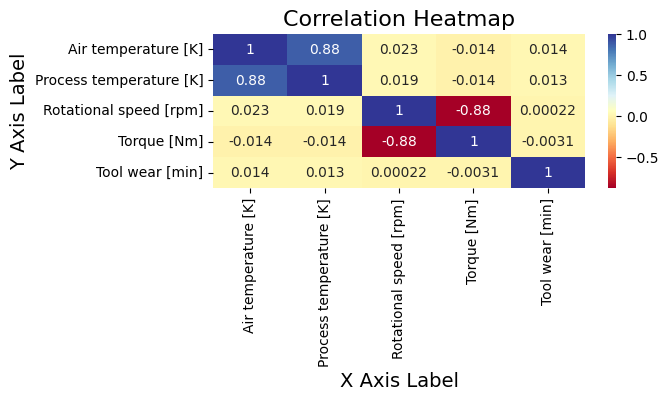

In [179]:
plt.figure(figsize=(6, 2))
ax = sns.heatmap(df.select_dtypes(include='number').corr(), annot=True, cmap="RdYlBu")
ax.set_title("Correlation Heatmap", fontsize=16)
ax.set_xlabel("X Axis Label", fontsize=14)
ax.set_ylabel("Y Axis Label", fontsize=14)
plt.tight_layout()
plt.show()

In [180]:
df.isnull().values.any()

np.False_

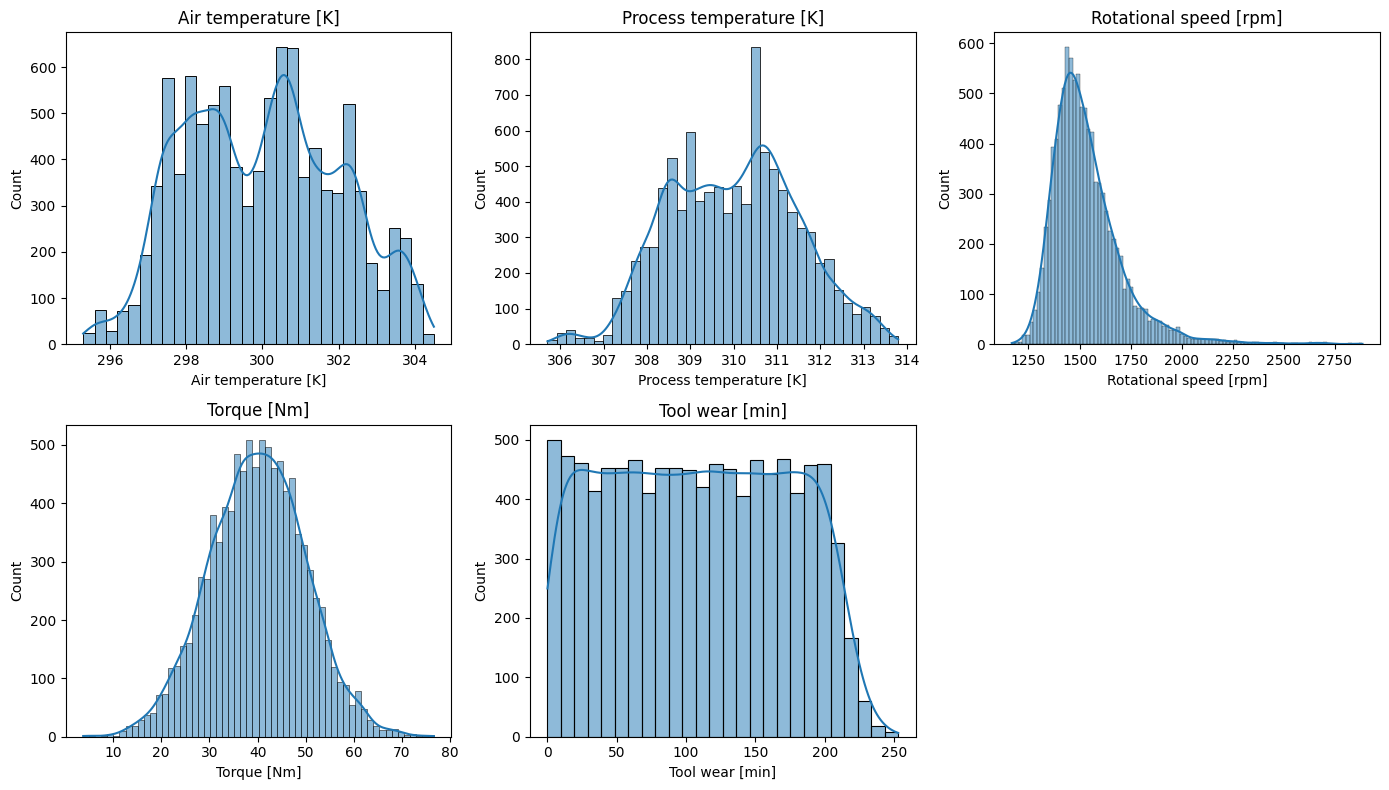

In [181]:
num_cols = df.select_dtypes(include='number').columns
n = len(num_cols)
ncols = 3
nrows = -(-n // ncols)  # ceiling division

plt.figure(figsize=(14, nrows * 4))
for i, col in enumerate(num_cols, 1):
    plt.subplot(nrows, ncols, i)
    sns.histplot(df[col], kde=True)
    plt.title(col)

plt.tight_layout()
plt.show()

In [182]:
#df.hist(figsize=(10, 6))


In [183]:
#df.describe()

Text(59.363666666666646, 0.5, 'Process temperature [K]')

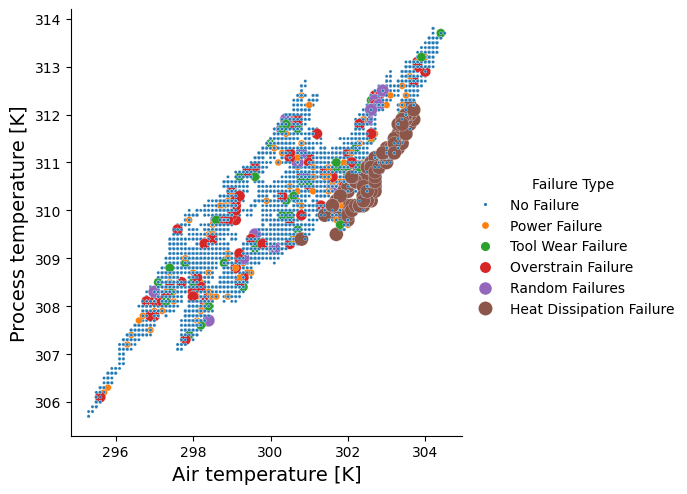

In [184]:
_ = sns.relplot(x="Air temperature [K]", y="Process temperature [K]", hue="Failure Type",size="Failure Type", sizes=(100, 5),data=df)
_.set_axis_labels('Air temperature [K]', 'Process temperature [K]')
_.ax.set_xlabel('Air temperature [K]', fontsize=14)
_.ax.set_ylabel('Process temperature [K]', fontsize=14)

Text(63.06379166666666, 0.5, 'Rotational speed [rpm]')

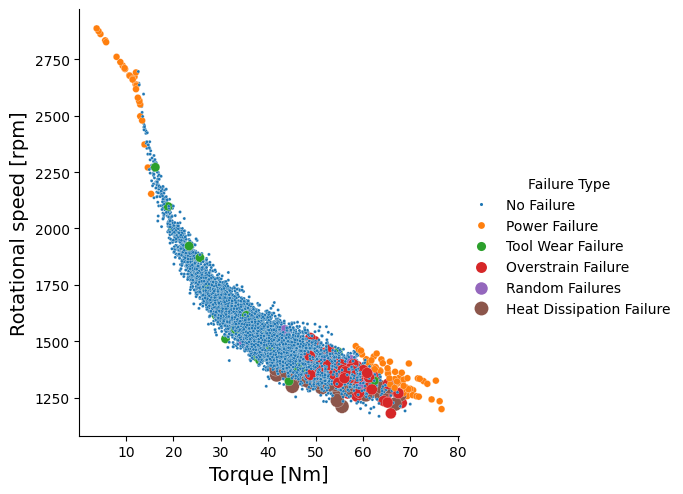

In [185]:
_ = sns.relplot(x="Torque [Nm]", y="Rotational speed [rpm]", hue="Failure Type",size="Failure Type", sizes=(100, 5),data=df)
_.set_axis_labels('Torque [Nm]', 'Rotational speed [rpm]')
_.ax.set_xlabel('Torque [Nm]', fontsize=14)
_.ax.set_ylabel('Rotational speed [rpm]', fontsize=14)

Text(63.06379166666666, 0.5, 'Rotational speed [rpm]')

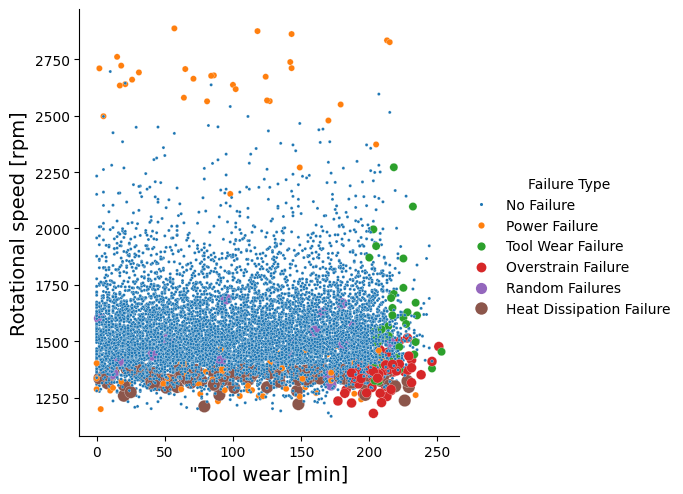

In [186]:
_ = sns.relplot(x="Tool wear [min]",
                y="Rotational speed [rpm]",
                hue="Failure Type",
                size="Failure Type",
                sizes=(80, 5),
                data=df)
_.set_axis_labels('"Tool wear [min]', 'Rotational speed [rpm]')
_.ax.set_xlabel('"Tool wear [min]', fontsize=14)
_.ax.set_ylabel('Rotational speed [rpm]', fontsize=14)

In [187]:
df["Failure Type"] = df["Failure Type"].replace({
    "No Failure": 0,
    "Heat Dissipation Failure": 1,
    "Power Failure": 2,
    "Overstrain Failure": 3,
    "Tool Wear Failure": 4,
    "Random Failures": 5
}).astype(int)

In [188]:
df["Type"] = df["Type"].replace({"H": 0, "L": 1, "M": 2}).astype(int)

In [189]:
col_name=df.columns.to_list()

In [190]:
predictive_columns = col_name[0:6]
X = df[predictive_columns]
y = df["Failure Type"]

In [191]:
from sklearn.model_selection import train_test_split
from sklearn.model_selection import StratifiedKFold
skf=StratifiedKFold(n_splits=5, random_state=None)
for train_index,test_index in skf.split(X,y):
    x1_train,x1_test=X.iloc[train_index],X.iloc[test_index]
    y1_train,y1_test=y.iloc[train_index],y.iloc[test_index]
    train_0, train_1 = len(y1_train[y1_train==0]), len(y1_train[y1_train==1])
    test_0, test_1 = len(y1_test[y1_test==0]), len(y1_test[y1_test==1])
    print('train: 0=%d, 1=%d, Test: 0=%d, 1=%d' % (train_0, train_1, test_0, test_1))

train: 0=7721, 1=90, Test: 0=1931, 1=22
train: 0=7721, 1=90, Test: 0=1931, 1=22
train: 0=7722, 1=90, Test: 0=1930, 1=22
train: 0=7722, 1=89, Test: 0=1930, 1=23
train: 0=7722, 1=89, Test: 0=1930, 1=23


In [192]:
X_train, X_test, y_train, y_test = train_test_split(
    X, y, random_state=40, test_size=0.33, stratify=y)

In [193]:
from imblearn.combine import SMOTETomek
smote = SMOTETomek(random_state=42)
X1_res, y1_res = smote.fit_resample(X_train,y_train)

In [194]:
X1_res.shape

(38748, 6)

In [195]:
X1_res

,Type,Air temperature [K],Process temperature [K],Rotational speed [rpm],Torque [Nm],Tool wear [min]
0,1,297.500000,308.700000,1371,46.500000,121
1,2,297.400000,308.600000,1452,41.200000,197
2,2,296.400000,307.300000,2077,19.100000,80
3,1,300.400000,309.300000,1413,50.300000,101
4,1,297.400000,308.100000,1348,57.400000,66
...,...,...,...,...,...,...
38743,1,302.567982,312.035964,1437,42.908492,201
38744,1,302.766184,312.183092,1507,36.246384,79
38745,1,299.733107,309.612309,1567,35.541596,183
38746,1,302.463023,311.872267,1308,59.649157,168


In [196]:
y1_res.shape

(38748,)

In [197]:
df_x = pd.DataFrame(X1_res)

In [198]:
df_x["Type"] = df_x["Type"].replace({0: "H", 1: "L", 2: "M"})

In [199]:
df_y = pd.DataFrame(y1_res)
df_y["Failure Type"] = df_y["Failure Type"].replace({
    0: "No Failure",
    1: "Heat Dissipation Failure",
    2: "Power Failure",
    3: "Overstrain Failure",
    4: "Tool Wear Failure",
    5: "Random Failures"
})
df1 = pd.concat([df_x, df_y], axis=1)
df1['Failure Type'].value_counts()

Failure Type
Overstrain Failure          6467
Heat Dissipation Failure    6464
Power Failure               6462
Tool Wear Failure           6461
Random Failures             6454
No Failure                  6440
Name: count, dtype: int64

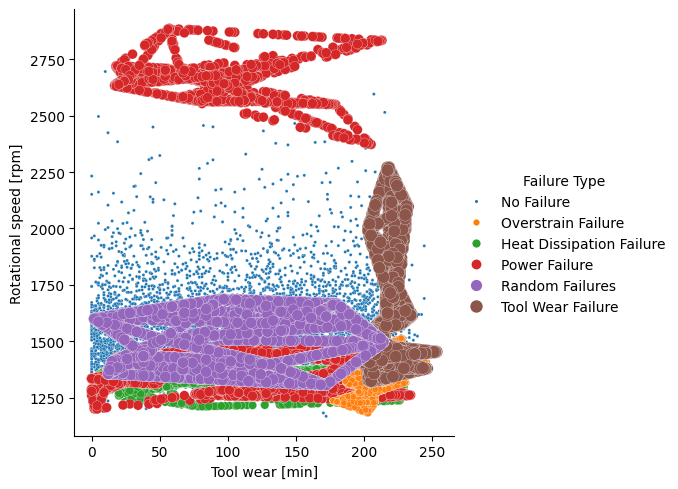

In [200]:
_ = sns.relplot(x="Tool wear [min]",
                y="Rotational speed [rpm]",
                hue="Failure Type",
                size="Failure Type",
                sizes=(80, 5),
                data=df1)

In [201]:
X_test.shape

(3300, 6)

In [202]:
y_test.shape

(3300,)

In [203]:
from sklearn.ensemble import RandomForestClassifier
from sklearn.multiclass import OutputCodeClassifier
from sklearn.pipeline import make_pipeline
from sklearn.compose import ColumnTransformer
from sklearn.preprocessing import OneHotEncoder
from sklearn.preprocessing import PowerTransformer
from sklearn.preprocessing import StandardScaler
# Build categorical preprocessor
categorical_cols = X.select_dtypes(include="object").columns.to_list()
categorical_pipe = make_pipeline(OneHotEncoder(sparse_output=False, handle_unknown="ignore"))

# Build numeric processor
to_log = ["Rotational speed [rpm]",	"Tool wear [min]"]
to_scale = ["Air temperature [K]","Process temperature [K]", "Torque [Nm]"]
numeric_pipe_1 = make_pipeline(PowerTransformer())
numeric_pipe_2 = make_pipeline(StandardScaler())

# Full processor
full = ColumnTransformer(
    transformers=[
        ("categorical", categorical_pipe, categorical_cols),
        ("power_transform", numeric_pipe_1, to_log),
        ("standardization", numeric_pipe_2, to_scale)
    ],
    verbose_feature_names_out=False  # keeps clean column names
)

In [204]:
##This is to transform the data into a format that can be used by the model. to wrap the data into a dataframe. otherwise it will be a numpy array.
# For training data
X_train_transformed = pd.DataFrame(
    full.fit_transform(X_train),
    columns=full.get_feature_names_out()
)

# For test data
X_test_transformed = pd.DataFrame(
    full.transform(X_test),
    columns=full.get_feature_names_out()
)

In [205]:
rfc = OutputCodeClassifier(RandomForestClassifier(), code_size=6, random_state=40)

In [206]:
from sklearn.metrics import f1_score,fbeta_score,matthews_corrcoef, log_loss, confusion_matrix,classification_report,make_scorer,balanced_accuracy_score
from sklearn.metrics import accuracy_score, roc_curve, auc,recall_score,roc_auc_score, average_precision_score, precision_score,precision_recall_curve,ConfusionMatrixDisplay, confusion_matrix
from sklearn.pipeline import Pipeline, make_pipeline
# Final pipeline combined with RandomForest
pipeline = Pipeline(
    steps=[("preprocess", full), ("base", rfc)]
).set_output(transform="pandas")

In [207]:
model_rfc = pipeline.fit(X1_res, y1_res)
y_pred_rfc = model_rfc.predict(X_test)

              precision    recall  f1-score   support

           0       0.99      0.95      0.97      3185
           1       0.37      0.57      0.45        37
           2       0.49      0.61      0.54        31
           3       0.67      0.77      0.71        26
           4       0.05      0.20      0.08        15
           5       0.00      0.00      0.00         6

    accuracy                           0.94      3300
   macro avg       0.43      0.52      0.46      3300
weighted avg       0.97      0.94      0.95      3300



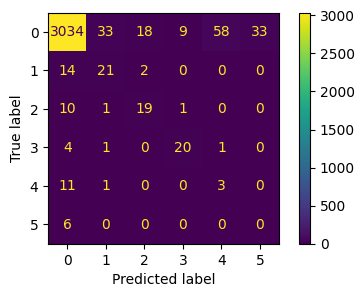

In [208]:
# Plot the confusion matrix
fig, ax = plt.subplots(figsize=(5, 3))
print(classification_report(y_test, y_pred_rfc))
# Create the matrix
cm = confusion_matrix(y_test, y_pred_rfc)
cmp = ConfusionMatrixDisplay(confusion_matrix=cm, display_labels=pipeline.classes_)
cmp.plot(ax=ax)
plt.show();

In [209]:
print(classification_report(y_test, y_pred_rfc))

              precision    recall  f1-score   support

           0       0.99      0.95      0.97      3185
           1       0.37      0.57      0.45        37
           2       0.49      0.61      0.54        31
           3       0.67      0.77      0.71        26
           4       0.05      0.20      0.08        15
           5       0.00      0.00      0.00         6

    accuracy                           0.94      3300
   macro avg       0.43      0.52      0.46      3300
weighted avg       0.97      0.94      0.95      3300



In [210]:
print("Accuracy Score: %.4f" %(accuracy_score(y_test,y_pred_rfc)))
print("Matthews correlation coefficient: %.4f" %(matthews_corrcoef(y_test,y_pred_rfc)))

Accuracy Score: 0.9385
Matthews correlation coefficient: 0.4005


In [211]:
import re

# Clean column names for LightGBM (it doesn't support special characters)
def clean_columns(df):
    df.columns = [re.sub(r'[^A-Za-z0-9_]', '_', col) for col in df.columns]
    return df

X1_res = clean_columns(X1_res)
X_test = clean_columns(X_test)

# Update column lists to match cleaned names
categorical_cols = [re.sub(r'[^A-Za-z0-9_]', '_', col) for col in categorical_cols]
to_log = [re.sub(r'[^A-Za-z0-9_]', '_', col) for col in to_log]
to_scale = [re.sub(r'[^A-Za-z0-9_]', '_', col) for col in to_scale]

# Rebuild full transformer with cleaned column names
full_lgbm = ColumnTransformer(
    transformers=[
        ("categorical", categorical_pipe, categorical_cols),
        ("power_transform", numeric_pipe_1, to_log),
        ("standardization", numeric_pipe_2, to_scale)
    ],
    verbose_feature_names_out=False
).set_output(transform="pandas")

# LGBM pipeline
from lightgbm import LGBMClassifier
lgbm = OutputCodeClassifier(LGBMClassifier(), code_size=6, random_state=42)

pipeline_lgbm = Pipeline(
    steps=[
        ("preprocess", full_lgbm),
        ("base", lgbm)
    ]
).set_output(transform="pandas")

In [212]:
model_lgbm = pipeline_lgbm.fit(X1_res, y1_res)
y_pred_lgbm = model_lgbm.predict(X_test)

[LightGBM] [Info] Number of positive: 12902, number of negative: 25846
[LightGBM] [Info] Auto-choosing col-wise multi-threading, the overhead of testing was 0.000423 seconds.
You can set `force_col_wise=true` to remove the overhead.
[LightGBM] [Info] Total Bins 1049
[LightGBM] [Info] Number of data points in the train set: 38748, number of used features: 5
[LightGBM] [Info] [binary:BoostFromScore]: pavg=0.332972 -> initscore=-0.694774
[LightGBM] [Info] Start training from score -0.694774
[LightGBM] [Info] Number of positive: 32281, number of negative: 6467
[LightGBM] [Info] Auto-choosing row-wise multi-threading, the overhead of testing was 0.000133 seconds.
You can set `force_row_wise=true` to remove the overhead.
And if memory is not enough, you can set `force_col_wise=true`.
[LightGBM] [Info] Total Bins 1049
[LightGBM] [Info] Number of data points in the train set: 38748, number of used features: 5
[LightGBM] [Info] [binary:BoostFromScore]: pavg=0.833101 -> initscore=1.607766
[Light

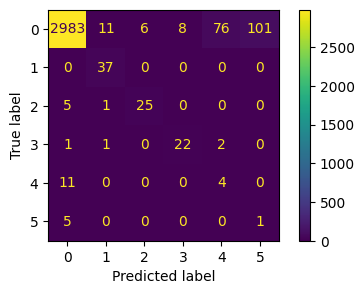

              precision    recall  f1-score   support

           0       0.99      0.94      0.96      3185
           1       0.74      1.00      0.85        37
           2       0.81      0.81      0.81        31
           3       0.73      0.85      0.79        26
           4       0.05      0.27      0.08        15
           5       0.01      0.17      0.02         6

    accuracy                           0.93      3300
   macro avg       0.56      0.67      0.58      3300
weighted avg       0.98      0.93      0.95      3300



In [213]:
# Plot the confusion matrix
fig, ax = plt.subplots(figsize=(5, 3))
# Create the matrix
cm = confusion_matrix(y_test, y_pred_lgbm)
cmp = ConfusionMatrixDisplay(confusion_matrix=cm, display_labels=pipeline.classes_)
cmp.plot(ax=ax)
plt.show();
print(classification_report(y_test, y_pred_lgbm))

In [214]:
print("Accuracy Score: %.4f" %(accuracy_score(y_test,y_pred_lgbm)))
print("Matthews correlation coefficient: %.4f" %(matthews_corrcoef(y_test,y_pred_lgbm)))

Accuracy Score: 0.9309
Matthews correlation coefficient: 0.4804


In [215]:
from xgboost import XGBClassifier

In [216]:
xgb = OutputCodeClassifier(XGBClassifier(), code_size=6, random_state=42)

In [219]:
pipeline_xgb = Pipeline(
    steps=[("preprocess", full_lgbm), ("base", xgb)]
).set_output(transform="pandas")

model_xgb = pipeline_xgb.fit(X1_res, y1_res)
y_pred_xgb = model_xgb.predict(X_test)

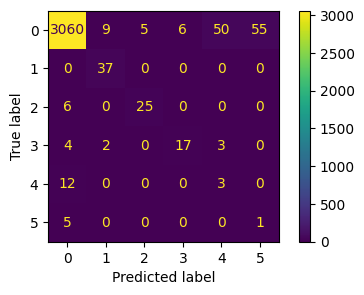

              precision    recall  f1-score   support

           0       0.99      0.96      0.98      3185
           1       0.77      1.00      0.87        37
           2       0.83      0.81      0.82        31
           3       0.74      0.65      0.69        26
           4       0.05      0.20      0.08        15
           5       0.02      0.17      0.03         6

    accuracy                           0.95      3300
   macro avg       0.57      0.63      0.58      3300
weighted avg       0.98      0.95      0.97      3300



In [220]:
# Plot the confusion matrix
fig, ax = plt.subplots(figsize=(5, 3))
# Create the matrix
cm = confusion_matrix(y_test, y_pred_xgb)
cmp = ConfusionMatrixDisplay(confusion_matrix=cm, display_labels=pipeline.classes_)
cmp.plot(ax=ax)
plt.show();
print(classification_report(y_test, y_pred_xgb))

In [221]:
print("Accuracy Score: %.4f" %(accuracy_score(y_test,y_pred_lgbm)))
print("Matthews correlation coefficient: %.4f" %(matthews_corrcoef(y_test,y_pred_lgbm)))

Accuracy Score: 0.9309
Matthews correlation coefficient: 0.4804


In [222]:
!pip install catboost

   ---------------------------------------- 0.0/100.2 MB ? eta -:--:--
    --------------------------------------- 1.3/100.2 MB 11.3 MB/s eta 0:00:09
   - -------------------------------------- 4.2/100.2 MB 13.2 MB/s eta 0:00:08
   -- ------------------------------------- 7.1/100.2 MB 14.1 MB/s eta 0:00:07
   --- ------------------------------------ 9.7/100.2 MB 13.7 MB/s eta 0:00:07
   ----- ---------------------------------- 12.6/100.2 MB 13.8 MB/s eta 0:00:07
   ------ --------------------------------- 15.5/100.2 MB 13.9 MB/s eta 0:00:07
   ------- -------------------------------- 18.4/100.2 MB 13.8 MB/s eta 0:00:06
   -------- ------------------------------- 21.0/100.2 MB 14.0 MB/s eta 0:00:06
   --------- ------------------------------ 24.1/100.2 MB 13.9 MB/s eta 0:00:06
   ---------- ----------------------------- 27.0/100.2 MB 14.0 MB/s eta 0:00:06
   ----------- ---------------------------- 29.9/100.2 MB 14.0 MB/s eta 0:00:06
   ------------ --------------------------- 32.5/100.


[notice] A new release of pip is available: 24.2 -> 26.1.1
[notice] To update, run: C:\Users\Muhammad Aqib\AppData\Local\Programs\Python\Python312\python.exe -m pip install --upgrade pip


In [223]:
from catboost import CatBoostClassifier, Pool, cv

In [224]:
catb = OutputCodeClassifier(CatBoostClassifier(random_seed=42,logging_level='Silent'), code_size=6, random_state=42)
pipeline_catb = Pipeline(steps=[("preprocess", full),("base",catb)])
model_catb = catb.fit(X1_res, y1_res)
y_pred_catb = model_catb.predict(X_test)


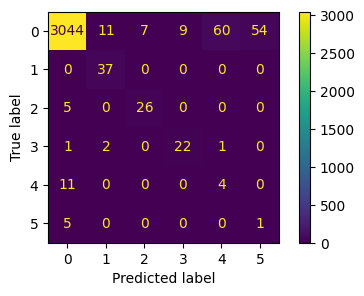

              precision    recall  f1-score   support

           0       0.99      0.96      0.97      3185
           1       0.74      1.00      0.85        37
           2       0.79      0.84      0.81        31
           3       0.71      0.85      0.77        26
           4       0.06      0.27      0.10        15
           5       0.02      0.17      0.03         6

    accuracy                           0.95      3300
   macro avg       0.55      0.68      0.59      3300
weighted avg       0.98      0.95      0.96      3300



In [225]:
# Plot the confusion matrix
fig, ax = plt.subplots(figsize=(5, 3))
# Create the matrix
cm = confusion_matrix(y_test, y_pred_catb)
cmp = ConfusionMatrixDisplay(confusion_matrix=cm, display_labels=pipeline.classes_)
cmp.plot(ax=ax)
plt.show();
print(classification_report(y_test, y_pred_catb))

In [226]:
print("Accuracy Score: %.4f" %(accuracy_score(y_test,y_pred_catb)))
print("Matthews correlation coefficient: %.4f" %(matthews_corrcoef(y_test,y_pred_catb)))

Accuracy Score: 0.9497
Matthews correlation coefficient: 0.5461


In [227]:
from sklearn.multiclass import OneVsRestClassifier
from sklearn.multiclass import OneVsOneClassifier
catb_ov = CatBoostClassifier()
ovr = OneVsRestClassifier(catb_ov)

In [228]:
ovr.fit(X1_res, y1_res)
yhat_ovr = ovr.predict(X_test)

Learning rate set to 0.049104
0:	learn: 0.6323084	total: 8.41ms	remaining: 8.4s
1:	learn: 0.5766382	total: 16.6ms	remaining: 8.26s
2:	learn: 0.5331693	total: 24.9ms	remaining: 8.27s
3:	learn: 0.4925910	total: 32.8ms	remaining: 8.16s
4:	learn: 0.4604435	total: 40ms	remaining: 7.96s
5:	learn: 0.4327783	total: 47.8ms	remaining: 7.92s
6:	learn: 0.4108184	total: 55.8ms	remaining: 7.91s
7:	learn: 0.3882556	total: 64.6ms	remaining: 8.01s
8:	learn: 0.3730292	total: 73.4ms	remaining: 8.08s
9:	learn: 0.3518720	total: 82.5ms	remaining: 8.17s
10:	learn: 0.3359160	total: 90.4ms	remaining: 8.13s
11:	learn: 0.3239285	total: 98.1ms	remaining: 8.08s
12:	learn: 0.3114504	total: 106ms	remaining: 8.04s
13:	learn: 0.3012471	total: 115ms	remaining: 8.12s
14:	learn: 0.2916469	total: 123ms	remaining: 8.11s
15:	learn: 0.2819418	total: 131ms	remaining: 8.05s
16:	learn: 0.2738198	total: 139ms	remaining: 8.01s
17:	learn: 0.2687345	total: 146ms	remaining: 7.98s
18:	learn: 0.2620493	total: 154ms	remaining: 7.94s
19

In [229]:
pipeline = Pipeline(
    steps=[("preprocess", full),("base",ovr)])

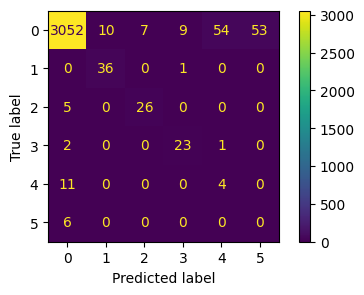

              precision    recall  f1-score   support

           0       0.99      0.96      0.97      3185
           1       0.78      0.97      0.87        37
           2       0.79      0.84      0.81        31
           3       0.70      0.88      0.78        26
           4       0.07      0.27      0.11        15
           5       0.00      0.00      0.00         6

    accuracy                           0.95      3300
   macro avg       0.55      0.65      0.59      3300
weighted avg       0.98      0.95      0.96      3300



In [230]:
# Plot the confusion matrix
fig, ax = plt.subplots(figsize=(5, 3))
# Create the matrix
cm = confusion_matrix(y_test, yhat_ovr)
cmp = ConfusionMatrixDisplay(confusion_matrix=cm, display_labels=pipeline.classes_)
cmp.plot(ax=ax)
plt.show();
print(classification_report(y_test, yhat_ovr))

In [231]:
print("Balanced Accuracy Score: %.4f" %(balanced_accuracy_score(y_test, yhat_ovr)))
print("Accuracy Score: %.4f" %(accuracy_score(y_test, yhat_ovr)))
print("Matthews correlation coefficient: %.4f" %(matthews_corrcoef(y_test, yhat_ovr)))

Balanced Accuracy Score: 0.6535
Accuracy Score: 0.9518
Matthews correlation coefficient: 0.5492


In [232]:
catb_ovo = CatBoostClassifier()
ovo = OneVsOneClassifier(catb_ovo)

In [233]:
ovo.fit(X1_res, y1_res)
yhat_ovo = ovo.predict(X_test)

Learning rate set to 0.030705
0:	learn: 0.6176632	total: 6.97ms	remaining: 6.96s
1:	learn: 0.5471169	total: 14.3ms	remaining: 7.12s
2:	learn: 0.4854801	total: 20.5ms	remaining: 6.8s
3:	learn: 0.4335120	total: 26ms	remaining: 6.47s
4:	learn: 0.3893884	total: 32.2ms	remaining: 6.41s
5:	learn: 0.3491452	total: 38.1ms	remaining: 6.31s
6:	learn: 0.3122629	total: 43.7ms	remaining: 6.2s
7:	learn: 0.2781418	total: 49.2ms	remaining: 6.1s
8:	learn: 0.2503753	total: 54.5ms	remaining: 6s
9:	learn: 0.2251028	total: 60ms	remaining: 5.94s
10:	learn: 0.2031221	total: 65.3ms	remaining: 5.87s
11:	learn: 0.1792218	total: 70.8ms	remaining: 5.83s
12:	learn: 0.1622441	total: 77.4ms	remaining: 5.87s
13:	learn: 0.1481496	total: 82.9ms	remaining: 5.84s
14:	learn: 0.1362959	total: 88.6ms	remaining: 5.82s
15:	learn: 0.1250623	total: 94.8ms	remaining: 5.83s
16:	learn: 0.1168150	total: 101ms	remaining: 5.82s
17:	learn: 0.1064346	total: 107ms	remaining: 5.82s
18:	learn: 0.0980770	total: 112ms	remaining: 5.8s
19:	le

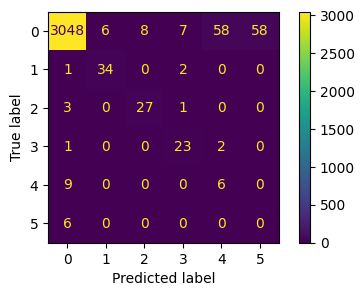

              precision    recall  f1-score   support

           0       0.99      0.96      0.97      3185
           1       0.85      0.92      0.88        37
           2       0.77      0.87      0.82        31
           3       0.70      0.88      0.78        26
           4       0.09      0.40      0.15        15
           5       0.00      0.00      0.00         6

    accuracy                           0.95      3300
   macro avg       0.57      0.67      0.60      3300
weighted avg       0.98      0.95      0.97      3300



In [234]:
# Plot the confusion matrix
fig, ax = plt.subplots(figsize=(5, 3))
# Create the matrix
cm = confusion_matrix(y_test, yhat_ovo)
cmp = ConfusionMatrixDisplay(confusion_matrix=cm, display_labels=pipeline.classes_)
cmp.plot(ax=ax)
plt.show();
print(classification_report(y_test, yhat_ovo))

In [235]:
print("Balanced Accuracy Score: %.4f" %(balanced_accuracy_score(y_test, yhat_ovo)))
print("Accuracy Score: %.4f" %(accuracy_score(y_test, yhat_ovo)))
print("Matthews correlation coefficient: %.4f" %(matthews_corrcoef(y_test, yhat_ovo)))

Balanced Accuracy Score: 0.6719
Accuracy Score: 0.9509
Matthews correlation coefficient: 0.5551


In [236]:
rfc_ov = RandomForestClassifier()

In [237]:
ovr = OneVsRestClassifier(rfc_ov)
ovr.fit(X1_res, y1_res)
yhat_ovr = ovr.predict(X_test)

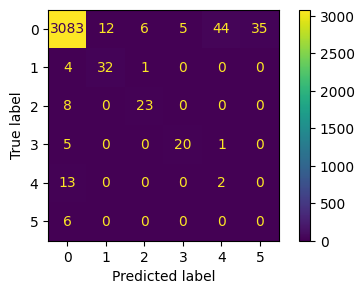

              precision    recall  f1-score   support

           0       0.99      0.97      0.98      3185
           1       0.73      0.86      0.79        37
           2       0.77      0.74      0.75        31
           3       0.80      0.77      0.78        26
           4       0.04      0.13      0.06        15
           5       0.00      0.00      0.00         6

    accuracy                           0.96      3300
   macro avg       0.55      0.58      0.56      3300
weighted avg       0.98      0.96      0.97      3300



In [238]:
# Plot the confusion matrix
fig, ax = plt.subplots(figsize=(5, 3))
# Create the matrix
cm = confusion_matrix(y_test, yhat_ovr)
cmp = ConfusionMatrixDisplay(confusion_matrix=cm, display_labels=pipeline.classes_)
cmp.plot(ax=ax)
plt.show();
print(classification_report(y_test, yhat_ovr))

In [239]:
print("Balanced Accuracy Score: %.4f" %(balanced_accuracy_score(y_test, yhat_ovr)))
print("Accuracy Score: %.4f" %(accuracy_score(y_test, yhat_ovr)))
print("Matthews correlation coefficient: %.4f" %(matthews_corrcoef(y_test, yhat_ovr)))

Balanced Accuracy Score: 0.5796
Accuracy Score: 0.9576
Matthews correlation coefficient: 0.5290


In [240]:
ovo = OneVsOneClassifier(rfc_ov)
ovo.fit(X1_res, y1_res)
yhat_ovo = ovo.predict(X_test)

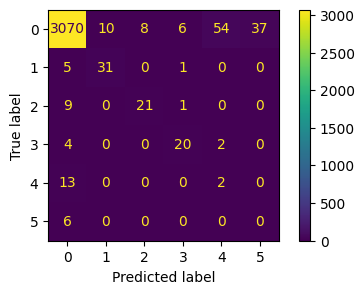

              precision    recall  f1-score   support

           0       0.99      0.96      0.98      3185
           1       0.76      0.84      0.79        37
           2       0.72      0.68      0.70        31
           3       0.71      0.77      0.74        26
           4       0.03      0.13      0.05        15
           5       0.00      0.00      0.00         6

    accuracy                           0.95      3300
   macro avg       0.54      0.56      0.54      3300
weighted avg       0.97      0.95      0.96      3300



In [241]:
# Plot the confusion matrix
fig, ax = plt.subplots(figsize=(5, 3))
# Create the matrix
cm = confusion_matrix(y_test, yhat_ovo)
cmp = ConfusionMatrixDisplay(confusion_matrix=cm, display_labels=pipeline.classes_)
cmp.plot(ax=ax)
plt.show();
print(classification_report(y_test, yhat_ovo))

In [242]:
print("Balanced Accuracy Score: %.4f" %(balanced_accuracy_score(y_test, yhat_ovo)))
print("Accuracy Score: %.4f" %(accuracy_score(y_test, yhat_ovo)))
print("Matthews correlation coefficient: %.4f" %(matthews_corrcoef(y_test, yhat_ovo)))

Balanced Accuracy Score: 0.5636
Accuracy Score: 0.9527
Matthews correlation coefficient: 0.4975
